# GMEL Counterfactual Scenario Testing

This notebook lets you test **what-if scenarios** on the GMEL commuting flow prediction model.
You pick an origin–destination (OD) pair and modify a land-use feature of the origin census tract,
then compare the predicted flow before and after the modification.

**How it works:**
1. Load the dataset and the pre-trained GMEL model.
2. Modify a node feature of the origin (or destination) census tract.
3. Re-run the GNN on the modified graph to get new embeddings.
4. Feed the new embeddings into the GBRT predictor and compare predictions.

> ⚠️ Node features are **z-score normalised** inside `utils.load_dataset`.  
> All `delta` values in this notebook operate in that **normalised space** (i.e., units of standard deviations).  
> A helper cell below shows the current normalised value at the selected node so you can choose a meaningful delta.

## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import torch
import pickle
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt

import utils
from model import MyModel

warnings.filterwarnings(
    "ignore",
    message="Feature table contains NaN. 0 is used to fill these NaNs"
)

# ── Model configuration ───────────────────────────────────────────────────────
YEAR              = 2015
NUM_HIDDEN_LAYERS = 1
EMBEDDING_SIZE    = 128
MULTITASK_WEIGHTS = (0.5, 0.25, 0.25)
DEVICE            = "cpu"
device            = torch.device(DEVICE)

print(f"PyTorch: {torch.__version__}  |  Device: {device}")

PyTorch: 2.3.0  |  Device: cpu


## 2. Reference Tables

Run this section once to build lookup tables that let you identify:
- What borough / census tract a **node ID** corresponds to
- What land-use attribute a **feature index** corresponds to

In [2]:
# ── Node ID  →  BoroCT2010 mapping ───────────────────────────────────────────
MAPPING_PATH = "../data/CensusTract2010/mapping_NodeID2BoroCT2010.csv"
mapping_df   = pd.read_csv(MAPPING_PATH)

BOROUGH_CODES = {1: "Manhattan", 2: "Bronx", 3: "Brooklyn", 4: "Queens", 5: "Staten Island"}

mapping_df["borough"] = mapping_df["BoroCT2010"].astype(str).str[0].astype(int).map(BOROUGH_CODES)

node2ct  = mapping_df.set_index("node_id")["BoroCT2010"].to_dict()
ct2node  = mapping_df.set_index("BoroCT2010")["node_id"].to_dict()

print(f"Total nodes: {len(node2ct)}")
print()
print("Sample node → BoroCT2010 → borough:")
display(mapping_df.head(10))

Total nodes: 2168

Sample node → BoroCT2010 → borough:


,node_id,BoroCT2010,borough
0,0,1000100,Manhattan
1,1,1000201,Manhattan
2,2,1000202,Manhattan
3,3,1000500,Manhattan
4,4,1000600,Manhattan
5,5,1000700,Manhattan
6,6,1000800,Manhattan
7,7,1000900,Manhattan
8,8,1001001,Manhattan
9,9,1001002,Manhattan


In [3]:
# ── Feature index  →  column name mapping ────────────────────────────────────
# These are the 65 columns remaining after BoroCT2010 is set as the row index
# in utils.load_dataset.  The order matches numpy column indices 0–64.

FEAT_PATH = "../data/PLUTO/census_tract_attributes_from_pluto2015.csv"
feat_cols = pd.read_csv(FEAT_PATH, nrows=0).columns.tolist()
feat_cols.remove("BoroCT2010")          # removed when set as index

feat_index_df = pd.DataFrame({
    "index": range(len(feat_cols)),
    "feature_name": feat_cols
})

feat_name2idx = {name: i for i, name in enumerate(feat_cols)}

print(f"Total features: {len(feat_cols)}")
print()
display(feat_index_df)

Total features: 65



,index,feature_name
0,0,bldgclass_A
1,1,bldgclass_B
2,2,bldgclass_C
3,3,bldgclass_D
4,4,bldgclass_E
...,...,...
60,60,yearbuilt_2010s
61,61,specificarea_histdist
62,62,specificarea_landmark
63,63,far_builtfar_avg


## 3. Load Data, Graph, and Baseline Model

In [4]:
data      = utils.load_dataset(year=YEAR)
node_feats = data["node_feats"]          # shape (2168, 65) — z-score normalised
ct_adj    = data["ct_adjacency_withweight"]
distm     = data["distm"]

g_baseline = utils.build_graph_from_matrix(
    ct_adj,
    node_feats.astype(np.float32),
    device=DEVICE
).to(device)

print(f"Nodes: {data['num_nodes']}  |  Feature dims: {node_feats.shape[1]}")

Nodes: 2168  |  Feature dims: 65


In [5]:
def get_embeddings_from_graph(g, num_hidden_layers, embedding_size, multitask_weights, device):
    """Load checkpoint and compute embeddings for the given graph."""
    ckpt_path = (
        f"./models/model_state_layers{num_hidden_layers}_"
        f"emb{embedding_size}_multitask{multitask_weights}.pth"
    )
    model = MyModel(
        g=g,
        num_nodes=g.number_of_nodes(),
        in_dim=g.ndata["attr"].shape[1],
        h_dim=embedding_size,
        num_hidden_layers=num_hidden_layers,
        device=str(device),
        reg_param=0
    ).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    with torch.no_grad():
        src_emb = model(g).detach().cpu().numpy()
        dst_emb = model.forward2(g).detach().cpu().numpy()
    return src_emb, dst_emb


def make_features_from_pairs(pairs, src_emb, dst_emb, scaled_distm):
    """Concatenate src embedding, dst embedding, and travel distance for each OD pair."""
    pairs = np.asarray(pairs, dtype=int)
    feat_src  = src_emb[pairs[:, 0]]
    feat_dst  = dst_emb[pairs[:, 1]]
    feat_dist = scaled_distm[pairs[:, 0], pairs[:, 1]].reshape(-1, 1)
    return np.concatenate([feat_src, feat_dst, feat_dist], axis=1)


def load_gbrt(year, num_hidden_layers, embedding_size, multitask_weights):
    """Load saved GBRT or raise if not found."""
    path = (
        f"./models/gbrt_year{year}_layers{num_hidden_layers}_"
        f"emb{embedding_size}_multitask{multitask_weights}.pkl"
    )
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"GBRT model not found at {path}.\nRun make_pred.ipynb first."
        )
    with open(path, "rb") as f:
        gbrt = pickle.load(f)
    print("Loaded GBRT:", path)
    return gbrt

In [6]:
# Compute baseline embeddings from the current checkpoint.
# We do NOT load from the cached .npz here because that file may be from
# a different training run than the checkpoint, causing a mismatch where
# even DELTA=0 produces different predictions.

src_emb_baseline, dst_emb_baseline = get_embeddings_from_graph(
    g_baseline, NUM_HIDDEN_LAYERS, EMBEDDING_SIZE, MULTITASK_WEIGHTS, device
)

scaled_distm_baseline = (
    distm / distm.max()
    * np.max([src_emb_baseline.max(), dst_emb_baseline.max()])
)

gbrt = load_gbrt(YEAR, NUM_HIDDEN_LAYERS, EMBEDDING_SIZE, MULTITASK_WEIGHTS)

print("Baseline embedding shape:", src_emb_baseline.shape)

Loaded GBRT: ./models/gbrt_year2015_layers1_emb128_multitask(0.5, 0.25, 0.25).pkl
Baseline embedding shape: (2168, 128)


Raw PLUTO statistics loaded.
  min=nan  p5=nan  p25=nan  mean=0.717  p75=nan  p95=nan  max=nan  std=0.601


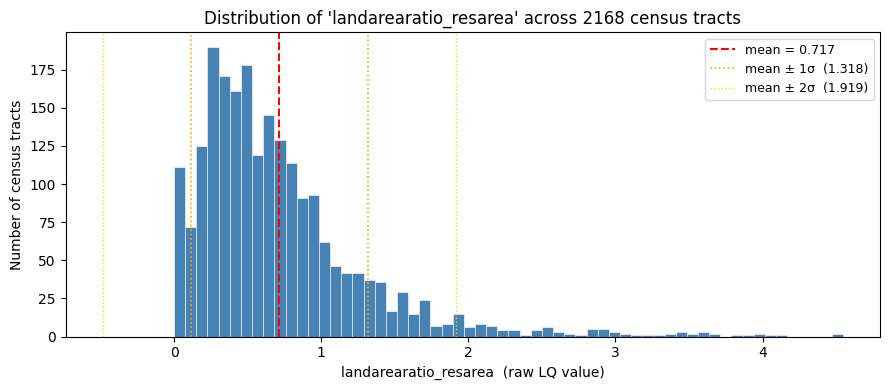

In [7]:
# ── Load raw PLUTO statistics for unit conversion ─────────────────────────────
# utils.load_dataset z-score normalises with column-wise mean/std.
# We recover those same statistics so we can convert raw LQ values ↔ normalised.

raw_pluto_df  = pd.read_csv(FEAT_PATH).set_index("BoroCT2010")[feat_cols]
feat_mean_raw = raw_pluto_df.mean().values
feat_std_raw  = raw_pluto_df.std().values

print("Raw PLUTO statistics loaded.")

# ── Distribution chart for a chosen feature ───────────────────────────────────
INSPECT_FEATURE = "landarearatio_resarea"   # change to any feature name

fidx   = feat_name2idx[INSPECT_FEATURE]
values = raw_pluto_df[INSPECT_FEATURE].values
mean_v = feat_mean_raw[fidx]
std_v  = feat_std_raw[fidx]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(values, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)

ax.axvline(mean_v,          color="red",    linestyle="--", linewidth=1.5, label=f"mean = {mean_v:.3f}")
ax.axvline(mean_v + std_v,  color="orange", linestyle=":",  linewidth=1.2, label=f"mean ± 1σ  ({mean_v+std_v:.3f})")
ax.axvline(mean_v - std_v,  color="orange", linestyle=":",  linewidth=1.2)
ax.axvline(mean_v + 2*std_v,color="gold",   linestyle=":",  linewidth=1.0, label=f"mean ± 2σ  ({mean_v+2*std_v:.3f})")
ax.axvline(mean_v - 2*std_v,color="gold",   linestyle=":",  linewidth=1.0)

ax.set_xlabel(f"{INSPECT_FEATURE}  (raw LQ value)")
ax.set_ylabel("Number of census tracts")
ax.set_title(f"Distribution of '{INSPECT_FEATURE}' across {len(values)} census tracts")
ax.legend(fontsize=9)

pct5, pct25, pct75, pct95 = np.percentile(values, [5, 25, 75, 95])
print(f"  min={values.min():.3f}  p5={pct5:.3f}  p25={pct25:.3f}  "
      f"mean={mean_v:.3f}  p75={pct75:.3f}  p95={pct95:.3f}  max={values.max():.3f}  std={std_v:.3f}")

plt.tight_layout()
plt.show()

## 4. Scenario Configuration

**Edit the four parameters below**, then run all remaining cells.

| Parameter | Description |
|---|---|
| `SRC_NODE` | Origin census tract (node ID, 0-indexed). Look up in the reference table above. |
| `DST_NODE` | Destination census tract (node ID). |
| `FEATURE_NAME` | Name of the land-use feature to modify. Must match a column in the reference table. |
| `DELTA` | How much to add to the **normalised** feature value at the origin node. |

> **Tip on choosing `DELTA`:** Because features are z-score normalised, `DELTA = 1.0` means shifting the feature by one standard deviation upward. The helper cell below shows the current normalised value so you can choose a realistic shift.

In [38]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║              EDIT THESE PARAMETERS                             ║
# ╚══════════════════════════════════════════════════════════════════╝

SRC_NODE      = 25    # origin of the OD pair to predict
DST_NODE      = 19    # destination of the OD pair to predict
MODIFIED_NODE = 19    # the node whose feature you want to change
                      # (can be SRC_NODE, DST_NODE, or any other node in the graph)

FEATURE_NAME  = "landarearatio_resarea"   # feature to modify on MODIFIED_NODE

# ── How to specify the change ──────────────────────────────────────────────────
# Option A — raw LQ units (recommended):
#   Set USE_RAW_TARGET = True and set TARGET_RAW_VALUE to the actual LQ value
#   you want the feature to become.
#
# Option B — normalised σ units:
#   Set USE_RAW_TARGET = False and set DELTA directly.

USE_RAW_TARGET   = True
TARGET_RAW_VALUE = 0   # target raw LQ value  (used when USE_RAW_TARGET = True)
DELTA            = 2.0   # shift in σ units      (used when USE_RAW_TARGET = False)

In [35]:
# ── Interpret the scenario ────────────────────────────────────────────────────
assert SRC_NODE      in node2ct,      f"SRC_NODE {SRC_NODE} not found in mapping table."
assert DST_NODE      in node2ct,      f"DST_NODE {DST_NODE} not found in mapping table."
assert MODIFIED_NODE in node2ct,      f"MODIFIED_NODE {MODIFIED_NODE} not found in mapping table."
assert FEATURE_NAME  in feat_name2idx, (
    f"'{FEATURE_NAME}' not found.\nValid names:\n" + "\n".join(feat_cols)
)

src_ct   = node2ct[SRC_NODE]
dst_ct   = node2ct[DST_NODE]
mod_ct   = node2ct[MODIFIED_NODE]
src_boro = BOROUGH_CODES[int(str(src_ct)[0])]
dst_boro = BOROUGH_CODES[int(str(dst_ct)[0])]
mod_boro = BOROUGH_CODES[int(str(mod_ct)[0])]
feat_idx = feat_name2idx[FEATURE_NAME]

norm_val = node_feats[MODIFIED_NODE, feat_idx]
raw_val  = feat_mean_raw[feat_idx] + norm_val * feat_std_raw[feat_idx]

if USE_RAW_TARGET:
    DELTA     = (TARGET_RAW_VALUE - raw_val) / feat_std_raw[feat_idx]
    raw_after = TARGET_RAW_VALUE
else:
    raw_after = raw_val + DELTA * feat_std_raw[feat_idx]

norm_after = norm_val + DELTA

print("━" * 60)
print(f"  Origin        : node {SRC_NODE}       →  BoroCT2010 {src_ct}  ({src_boro})")
print(f"  Destination   : node {DST_NODE}       →  BoroCT2010 {dst_ct}  ({dst_boro})")
print(f"  Modified node : node {MODIFIED_NODE}  →  BoroCT2010 {mod_ct}  ({mod_boro})")
print("━" * 60)
print(f"  Feature       : '{FEATURE_NAME}'  (index {feat_idx})")
print()
print(f"  Current value   raw LQ     : {raw_val:>10.4f}")
print(f"  Current value   normalised : {norm_val:>10.4f} σ")
print()
print(f"  Delta           normalised : {DELTA:>+10.4f} σ")
print()
print(f"  Modified value  raw LQ     : {raw_after:>10.4f}")
print(f"  Modified value  normalised : {norm_after:>10.4f} σ")
print("━" * 60)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Origin        : node 25       →  BoroCT2010 1002602  (Manhattan)
  Destination   : node 19       →  BoroCT2010 1002100  (Manhattan)
  Modified node : node 19  →  BoroCT2010 1002100  (Manhattan)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Feature       : 'landarearatio_resarea'  (index 43)

  Current value   raw LQ     :     1.9083
  Current value   normalised :     1.9829 σ

  Delta           normalised :   +13.4669 σ

  Modified value  raw LQ     :    10.0000
  Modified value  normalised :    15.4498 σ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 5. Run Scenarios

The modified feature matrix is fed back through the GNN to produce new node embeddings.
The GBRT predictor then estimates flow using those new embeddings.

In [36]:
# Apply modification to the chosen node
modified_feats = node_feats.copy()
modified_feats[MODIFIED_NODE, feat_idx] += DELTA

# Rebuild graph with modified features
g_modified = utils.build_graph_from_matrix(
    ct_adj,
    modified_feats.astype(np.float32),
    device=DEVICE
).to(device)

# Re-run GNN to get counterfactual embeddings
src_emb_mod, dst_emb_mod = get_embeddings_from_graph(
    g_modified, NUM_HIDDEN_LAYERS, EMBEDDING_SIZE, MULTITASK_WEIGHTS, device
)

scaled_distm_mod = (
    distm / distm.max()
    * np.max([src_emb_mod.max(), dst_emb_mod.max()])
)

print("Counterfactual embeddings computed.")

Counterfactual embeddings computed.


In [37]:
# Predict flow for the OD pair under both scenarios
pair = np.array([[SRC_NODE, DST_NODE]], dtype=int)

X_original = make_features_from_pairs(pair, src_emb_baseline, dst_emb_baseline, scaled_distm_baseline)
X_modified = make_features_from_pairs(pair, src_emb_mod,      dst_emb_mod,      scaled_distm_mod)

y_original = gbrt.predict(X_original)[0]
y_modified = gbrt.predict(X_modified)[0]
diff       = y_modified - y_original
pct_change = diff / y_original * 100 if y_original != 0 else float("nan")

print("━" * 55)
print(f"  OD pair     : {SRC_NODE} → {DST_NODE}  "
      f"({src_boro} → {dst_boro})")
print(f"  Feature     : '{FEATURE_NAME}'  Δ = {DELTA:+.2f} σ")
print("━" * 55)
print(f"  Baseline predicted flow   : {y_original:.4f}")
print(f"  Modified predicted flow   : {y_modified:.4f}")
print(f"  Absolute difference       : {diff:+.4f}")
print(f"  Relative change           : {pct_change:+.2f}%")
print("━" * 55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  OD pair     : 25 → 19  (Manhattan → Manhattan)
  Feature     : 'landarearatio_resarea'  Δ = +13.47 σ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Baseline predicted flow   : 29.8279
  Modified predicted flow   : 25.7167
  Absolute difference       : -4.1112
  Relative change           : -13.78%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 6. Multi-Feature Sweep (Optional)

Sweep a range of delta values for the selected feature and plot how predicted flow changes.

In [ ]:
import matplotlib.pyplot as plt

DELTA_RANGE = np.linspace(-3, 3, 13)   # e.g. -3σ to +3σ in 0.5σ steps

predicted_flows = []

for delta in DELTA_RANGE:
    mod_feats = node_feats.copy()
    mod_feats[SRC_NODE, feat_idx] += delta

    g_temp = utils.build_graph_from_matrix(
        ct_adj, mod_feats.astype(np.float32), device=DEVICE
    ).to(device)

    src_e, dst_e = get_embeddings_from_graph(
        g_temp, NUM_HIDDEN_LAYERS, EMBEDDING_SIZE, MULTITASK_WEIGHTS, device
    )
    s_distm = distm / distm.max() * np.max([src_e.max(), dst_e.max()])

    X = make_features_from_pairs(pair, src_e, dst_e, s_distm)
    predicted_flows.append(gbrt.predict(X)[0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(DELTA_RANGE, predicted_flows, marker="o")
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, label="baseline (Δ=0)")
ax.axhline(y_original, color="red", linestyle=":", linewidth=0.8, label=f"baseline flow = {y_original:.2f}")
ax.set_xlabel(f"Delta on '{FEATURE_NAME}' (normalised units, σ)")
ax.set_ylabel("Predicted commuting flow")
ax.set_title(
    f"Sensitivity: node {SRC_NODE} ({src_boro}) → node {DST_NODE} ({dst_boro})\n"
    f"Feature: {FEATURE_NAME}"
)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Notes and Caveats

- **Normalised feature space.** All `DELTA` values are in z-score units. The raw LQ features were normalised by `(x - mean) / std` in `utils.load_dataset`. A `DELTA = 1.0` means a one-standard-deviation upward shift.

- **Graph-level propagation.** GMEL is a graph neural network: modifying one node's features affects its embeddings *and* the embeddings of its graph neighbours through message passing. The counterfactual therefore captures indirect spatial spillovers, not just the direct effect on the selected node.

- **GBRT trained on baseline embeddings.** The GBRT predictor was fitted on embeddings from the unmodified graph. Using it with counterfactual embeddings is an approximation — predictions should be interpreted as directional signals, not exact flow values.

- **LQ features are relative measures.** A large `DELTA` on an LQ feature (e.g., `+10σ`) simulates a tract that is many standard deviations more specialised in a given land use than any tract in the city. Keep deltas within a plausible range (e.g., ±3σ) for interpretable results.

- **FAR features are not LQ-transformed.** `far_builtfar_avg` and `far_builtfar_std` are raw averages, not location quotients. Their standard deviations may differ from LQ features — check `feat_index_df` and interpret accordingly.